### Test PSF interpolation

In [35]:
import jax.numpy as jnp
import jax
from jax import grad, jit, vmap
from jax.lax import clamp
from functools import partial
from scipy.special import kn
import stpsf
# ── import plotting helpers ───────────────────────────────────────────────────
import sys
from pathlib import Path as Path2
path = Path2('~/code_package').expanduser()
sys.path.append(str(path))
import matplotlib.pyplot as plt
from my_astro_tools import my_im_show,set_plot_style
set_plot_style()

In [36]:
filter_name = 'F115W'
pixel_scale = 0.031
detector = 'NRCA1'
add_ipc = True
charge_diffusion_sigma = None
fov_pixels = 71
oversample = 4

In [37]:
nrc = stpsf.NIRCam()
nrc.filter     = filter_name
nrc.detector   = detector
nrc.pixelscale = pixel_scale
if not add_ipc:
    nrc.options["add_ipc"] = add_ipc
if charge_diffusion_sigma is not None:
    nrc.options["charge_diffusion_sigma"] = charge_diffusion_sigma

In [38]:
psf_hdul = nrc.calc_psf(
            fov_pixels = fov_pixels,
            oversample = oversample,
            normalize  = "last",
        )
psf_arr = psf_hdul["DET_DIST"].data.astype(jnp.float32)
psf_arr /= psf_arr.sum()   # unit-normalise

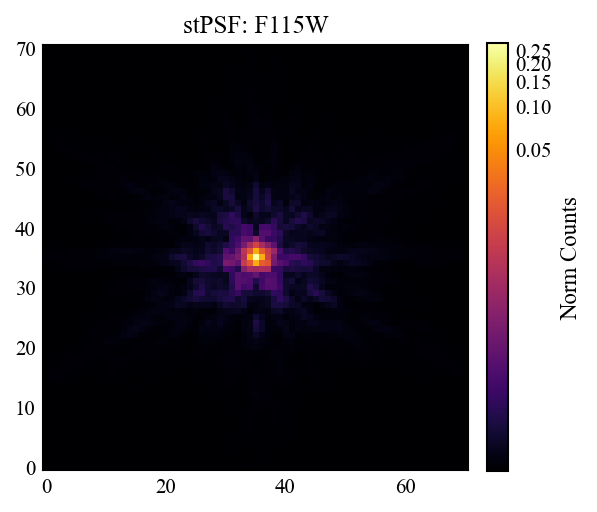

In [39]:
from astropy.visualization import simple_norm
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
norm_psf = simple_norm(psf_arr, stretch='log')
my_im_show(psf_arr, ax = ax, norm = norm_psf, cmap = 'inferno',
           title = f'stPSF: {filter_name}', cbar_label= 'Norm Counts')
plt.show()

In [40]:
def add_PSF(x,y,imnx,imny,psfimage,scalefactor=1.):
    ny0,nx0=psfimage.shape
    shiftx = x-0.5*nx0*scalefactor+0.5
    shifty = y-0.5*ny0*scalefactor+0.5
    scale = jnp.array([scalefactor,scalefactor], dtype=jnp.float32)
    trans = jnp.array([shifty,shiftx], dtype=jnp.float32)
    return jax.image.scale_and_translate(psfimage,(imny,imnx),(0,1),scale,trans,'cubic')/(scalefactor**2)

In [41]:
imnx = 71
imny = 71
x = jnp.linspace(41,42,20)
y = jnp.linspace(41,42,20)
for xi in x:
    for yi in y:
        psf_shifted = add_PSF(xi,yi,imnx,imny,psf_arr,scalefactor=1.)
        if jnp.sum(psf_shifted<0) > 0:
            print(xi, yi, jnp.sum(psf_shifted<0))

41.0 41.263157 1
41.0 41.31579 1
41.0 41.36842 1
41.0 41.42105 2
41.0 41.473686 2
41.0 41.526314 2
41.0 41.57895 2
41.0 41.631577 2
41.0 41.684208 1
41.0 41.73684 1
41.0 41.78947 1
41.0 41.842102 1
41.05263 41.263157 1
41.05263 41.31579 1
41.05263 41.36842 2
41.05263 41.42105 2
41.05263 41.473686 2
41.05263 41.526314 2
41.05263 41.57895 2
41.05263 41.631577 2
41.05263 41.684208 1
41.05263 41.73684 1
41.05263 41.78947 1
41.05263 41.842102 1
41.105263 41.263157 1
41.105263 41.31579 1
41.105263 41.36842 1
41.105263 41.42105 2
41.105263 41.473686 2
41.105263 41.526314 2
41.105263 41.57895 2
41.105263 41.631577 1
41.105263 41.684208 1
41.105263 41.73684 1
41.105263 41.78947 1
41.157898 41.263157 1
41.157898 41.31579 1
41.157898 41.36842 1
41.157898 41.42105 1
41.157898 41.473686 2
41.157898 41.526314 2
41.157898 41.57895 2
41.157898 41.631577 1
41.157898 41.684208 1
41.157898 41.73684 1
41.157898 41.78947 1
41.210526 41.263157 1
41.210526 41.31579 1
41.210526 41.36842 1
41.210526 41.42105 1

In [ ]:
imnx = 71
imny = 71
x, y = 41.947365, 41.631577
psf_shifted = add_PSF(x,y,imnx,imny,psf_arr,scalefactor=1.)
idx_neg = psf_shifted<0
print(x, y, jnp.sum(idx_neg))
rows, cols = x
print(cols, rows)
print(psf_shifted[rows, cols])

41.947365 41.631577 2
[42 42] [39 46]
[-1.1852764e-05 -5.7668080e-05]


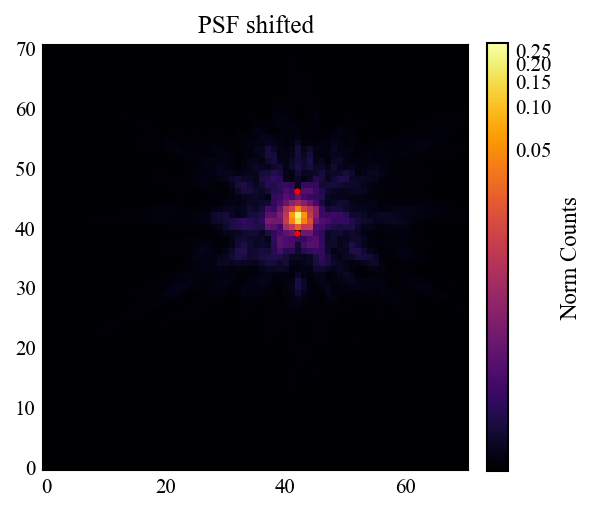

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
norm_psf = simple_norm(psf_arr, stretch='log')
my_im_show(psf_shifted, ax = ax, norm = norm_psf, cmap = 'inferno',
           title = f'PSF shifted', cbar_label= 'Norm Counts')
ax.plot(cols, rows, 'ro', markersize=2, label='Negative Pixels')
plt.show()